# InstantMesh Single-Mask Colored Showcase — Pretrained + I1–I4

Notebook ini khusus **InstantMesh saja**.

Target:
- 1 topeng Bali
- beberapa input view
- skenario:
  - `pretrained`
  - `I1`
  - `I2`
  - `I3`
  - `I4`
- output warna lengkap:
  - **native `OBJ + MTL + PNG texture`**
  - generated 6-view image
  - orbit video `.mp4`
  - optional vertex-colored preview mesh untuk Plotly
  - `preview.html`
- smoke test dan hard-check supaya tidak ada kasus “CSV ada tapi mesh kosong”.

Folder output:
```text
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/
```

Yang dianggap sukses untuk output utama adalah **OBJ + MTL + PNG texture**. Kalau salah satu tidak ada, notebook akan stop di smoke test.

In [1]:
# Cell 1 — Mount Google Drive
from google.colab import drive
import os

os.makedirs('/content/drive', exist_ok=True)
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# Cell 2 — User config

from pathlib import Path

# Input topeng: 000 sudah center dan hadap depan.
INPUT_RGB_000 = r"My Drive\Tugas_Akhir\Dataset\BaliMask3D\Renders_bali36_v1\1\rgb\000.png"

# Dipilih representatif agar Colab masih aman.
# Kalau mau semua 36 view, ubah menjadi: [f"{i:03d}" for i in range(36)]
SELECTED_VIEW_STEMS = ["000", "006", "012", "018", "024", "030"]

# Checkpoint InstantMesh fine-tuning
IM_I1_CKPT = r"My Drive\Tugas_Akhir\Outputs\finetune\instantmesh_finetune_balimask_I1\checkpoints\Salinan best_meshval_combined_I1_depthnormal.pt"
IM_I2_CKPT = r"My Drive\Tugas_Akhir\Outputs\finetune\instantmesh_finetune_balimask_I2\checkpoints\p\Salinan best_meshval_combined_I2_supervision_same_trainable.pt"
IM_I3_CKPT = r"My Drive\Tugas_Akhir\Outputs\finetune\instantmesh_finetune_balimask_I3\checkpoints\p\Salinan best_meshval_combined_I3_trainable_plus_supervision.pt"
IM_I4_CKPT = r"My Drive\Tugas_Akhir\Outputs\finetune\instantmesh_finetune_balimask_I4\checkpoints\p\Salinan best_meshval_combined_I4_topology_aware_max.pt"

# Output utama
OUTPUT_ROOT_REL = r"My Drive\Tugas_Akhir\Outputs\Showcase\instantmesh_only"

# Optional: isi manual kalau auto-detect mask folder gagal.
MASK_DIR_OVERRIDE = ""

# InstantMesh params
IM_CONFIG_NAME = "instant-mesh-large"
DIFFUSION_STEPS = 75
IM_VIEW = 6
IMAGE_SIZE = 320
IM_DISTANCE = 4.5
IM_SCALE = 1.0
USE_FP16_PIPELINE = True
SAVE_VIDEO = True
EXPORT_TEXMAP = True
FORCE_RERUN = False

# Showcase params
SHOWCASE_MAX_ROWS_PER_SCENARIO = 3
SAVE_PLOTLY_HTML = True

# Preview conversion:
# Native OBJ+MTL+PNG adalah output utama. Ini hanya untuk membuat preview HTML berwarna.
MAKE_VERTEX_COLORED_PREVIEW = True

In [3]:
# Cell 3 — Common helpers, path resolver, input preparation

import os, json, shutil, random, subprocess, sys, math
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def to_colab_drive_path(path_like: str) -> str:
    s = str(path_like).strip().strip('"').strip("'").replace("\\", "/")
    if s.startswith("/content/") or s.startswith("/mnt/"):
        return s
    if s.startswith("My Drive/"):
        return "/content/drive/MyDrive/" + s[len("My Drive/"):]
    if s.startswith("MyDrive/"):
        return "/content/drive/" + s
    if s.startswith("drive/MyDrive/"):
        return "/content/" + s
    return s

INPUT_RGB_000_ABS = Path(to_colab_drive_path(INPUT_RGB_000))
assert INPUT_RGB_000_ABS.exists(), f"RGB 000 tidak ditemukan: {INPUT_RGB_000_ABS}"

RGB_DIR = INPUT_RGB_000_ABS.parent
SCENE_ROOT = RGB_DIR.parent
MASK_ID = SCENE_ROOT.name

mask_candidates = []
if MASK_DIR_OVERRIDE:
    mask_candidates.append(Path(to_colab_drive_path(MASK_DIR_OVERRIDE)))
mask_candidates += [
    SCENE_ROOT / "mask",
    SCENE_ROOT / "masks",
    SCENE_ROOT / "alpha",
    SCENE_ROOT / "rgba_mask",
    SCENE_ROOT / "rgba",
]
MASK_DIR = next((p for p in mask_candidates if p.exists()), None)

OUTPUT_ROOT = Path(to_colab_drive_path(OUTPUT_ROOT_REL)) / f"mask_{MASK_ID}"
COMMON_ROOT = OUTPUT_ROOT / "_common"
RGBA_INPUT_ROOT = COMMON_ROOT / "rgba_inputs"
MANIFEST_ROOT = OUTPUT_ROOT / "_manifests"
LOG_ROOT = OUTPUT_ROOT / "_logs"
SHOWCASE_ROOT = OUTPUT_ROOT / "_showcase"

for p in [OUTPUT_ROOT, COMMON_ROOT, RGBA_INPUT_ROOT, MANIFEST_ROOT, LOG_ROOT, SHOWCASE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

def find_rgb_for_stem(stem: str):
    p = RGB_DIR / f"{stem}.png"
    if p.exists():
        return p
    alts = sorted(RGB_DIR.glob(f"{stem}.*"))
    return alts[0] if alts else None

def find_mask_for_stem(stem: str, view_name: str):
    if MASK_DIR is None:
        return None
    p = MASK_DIR / view_name
    if p.exists():
        return p
    alts = sorted(MASK_DIR.glob(f"{stem}.*"))
    return alts[0] if alts else None

def make_rgba(rgb_path: Path, mask_path, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    rgb = Image.open(rgb_path).convert("RGB")

    if mask_path and Path(mask_path).exists():
        mask = Image.open(mask_path).convert("L")
        if mask.size != rgb.size:
            mask = mask.resize(rgb.size, Image.NEAREST)
    else:
        mask = Image.new("L", rgb.size, 255)

    rgba = rgb.copy()
    rgba.putalpha(mask)
    rgba.save(out_path)
    return out_path

rows = []
for stem in SELECTED_VIEW_STEMS:
    rgb_path = find_rgb_for_stem(stem)
    if rgb_path is None or not Path(rgb_path).exists():
        print("[WARN] RGB tidak ditemukan:", stem)
        continue

    view_name = Path(rgb_path).name
    mask_path = find_mask_for_stem(stem, view_name)
    rgba_path = RGBA_INPUT_ROOT / view_name
    make_rgba(Path(rgb_path), mask_path, rgba_path)

    rows.append({
        "mask_id": MASK_ID,
        "view_stem": stem,
        "view_name": view_name,
        "rgb_path": str(rgb_path),
        "mask_path": str(mask_path) if mask_path else "",
        "mask_found": bool(mask_path and Path(mask_path).exists()),
        "rgba_input_path": str(rgba_path),
    })

input_df = pd.DataFrame(rows)
assert len(input_df) > 0, "Tidak ada view input valid."

input_manifest_csv = MANIFEST_ROOT / "input_manifest.csv"
input_df.to_csv(input_manifest_csv, index=False)

print("MASK_ID     :", MASK_ID)
print("RGB_DIR     :", RGB_DIR)
print("MASK_DIR    :", MASK_DIR)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("Saved       :", input_manifest_csv)
display(input_df)

MASK_ID     : 1
RGB_DIR     : /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/Renders_bali36_v1/1/rgb
MASK_DIR    : /content/drive/MyDrive/Tugas_Akhir/Dataset/BaliMask3D/Renders_bali36_v1/1/mask
OUTPUT_ROOT : /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1
Saved       : /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_manifests/input_manifest.csv


,mask_id,view_stem,view_name,rgb_path,mask_path,mask_found,rgba_input_path
0,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
1,1,006,006.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
2,1,012,012.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
3,1,018,018.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
4,1,024,024.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
5,1,030,030.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...


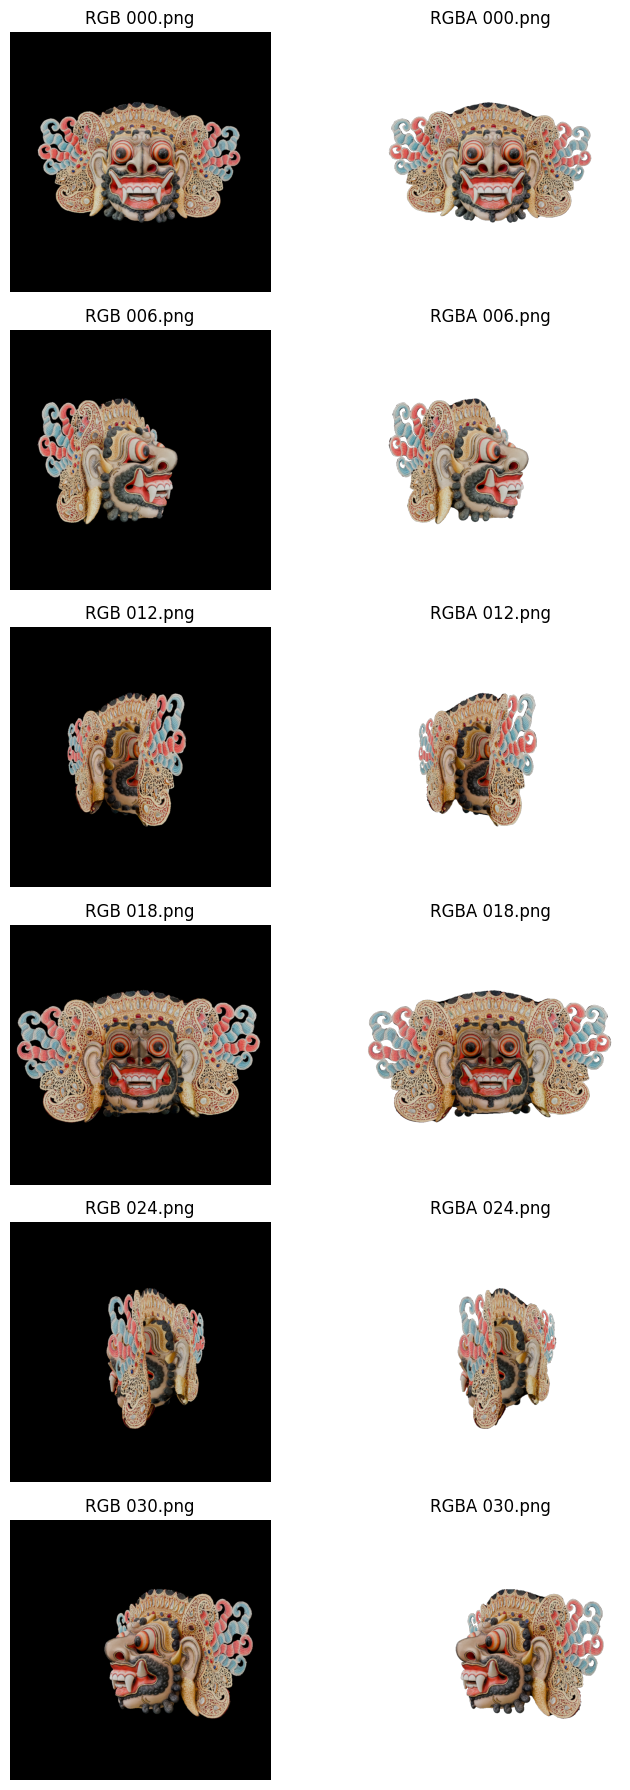

In [4]:
# Cell 4 — Preview selected RGB/RGBA inputs

n = len(input_df)
fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n))
if n == 1:
    axes = np.array([axes])

for i, row in enumerate(input_df.to_dict("records")):
    axes[i, 0].imshow(Image.open(row["rgb_path"]).convert("RGB"))
    axes[i, 0].set_title(f"RGB {row['view_name']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(Image.open(row["rgba_input_path"]).convert("RGBA"))
    axes[i, 1].set_title(f"RGBA {row['view_name']}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# Setup InstantMesh

Disarankan runtime Colab bersih. Notebook ini tidak dicampur TripoSR/Wonder3D supaya dependency tidak saling tabrak.

In [5]:
# Cell 5 — Setup InstantMesh repo + dependencies

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Tugas_Akhir")
REPO_ROOT = PROJECT_ROOT / "InstantMesh-clean"
RUNNER_PY = REPO_ROOT / "run_colab_instantmesh_ft_showcase.py"

FORCE_RECLONE_IM = False

%cd /content/drive/MyDrive/Tugas_Akhir

if FORCE_RECLONE_IM and REPO_ROOT.exists():
    !rm -rf InstantMesh-clean

if not REPO_ROOT.exists():
    !git clone https://github.com/TencentARC/InstantMesh.git InstantMesh-clean
else:
    print("Repo exists:", REPO_ROOT)

%cd /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean

# Hindari konflik dependency lama.
!pip -q uninstall -y huggingface_hub accelerate diffusers transformers pytorch-lightning lightning-fabric peft rembg cupy cupy-cuda12x cupy-cuda11x jax jaxlib flax chex orbax-checkpoint || true

!pip -q install -U pip setuptools wheel packaging jedi
!pip -q install numpy==1.26.4 scipy pandas openpyxl omegaconf einops
!pip -q install pillow opencv-python imageio imageio-ffmpeg matplotlib plotly trimesh xatlas plyfile PyMCubes
!pip -q install torchmetrics webdataset tensorboard safetensors sentencepiece
!pip -q install huggingface_hub==0.25.2 accelerate==0.27.2 diffusers==0.26.3 transformers==4.38.2
!pip -q install rembg pymatting ripser persim ninja

# nvdiffrast perlu untuk render/mesh extraction.
!pip -q install git+https://github.com/NVlabs/nvdiffrast.git --no-build-isolation

import numpy as np, trimesh
print("numpy  :", np.__version__)
print("trimesh:", trimesh.__version__)
print("InstantMesh setup done.")

/content/drive/.shortcut-targets-by-id/1OKbOAl3EJdjiW_r44luBzfMH-JjTT3JD/Tugas_Akhir
Repo exists: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean
/content/drive/.shortcut-targets-by-id/1OKbOAl3EJdjiW_r44luBzfMH-JjTT3JD/Tugas_Akhir/InstantMesh-clean
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 203.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires huggingface-hub>=0.23.0, which is not installed.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, which is not installed.
torchtune 0.6.1 requires huggingface_hub[hf_transfer], which is not installed.
timm 1.0.27 requires huggingface_hub, which is not installed.
torch 2.11.0+cu128 req

In [6]:
# Cell 6 — Write patched InstantMesh helper files and runner

from pathlib import Path
import py_compile

mesh_util_colab_py = REPO_ROOT / "src" / "utils" / "mesh_util_colab.py"
infer_util_colab_py = REPO_ROOT / "src" / "utils" / "infer_util_colab.py"

mesh_util_colab_py.write_text('\nimport os\nimport trimesh\nimport numpy as np\nfrom PIL import Image\n\ndef _to_numpy(x):\n    if isinstance(x, np.ndarray):\n        return x\n    if hasattr(x, "detach"):\n        return x.detach().cpu().numpy()\n    return np.asarray(x)\n\ndef save_obj(pointnp_px3, facenp_fx3, colornp_px3, fpath):\n    pointnp_px3 = _to_numpy(pointnp_px3).astype(np.float32)\n    facenp_fx3 = _to_numpy(facenp_fx3).astype(np.int64)\n    colornp_px3 = _to_numpy(colornp_px3)\n\n    pointnp_px3 = pointnp_px3 @ np.array([[1, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=np.float32)\n    facenp_fx3 = facenp_fx3[:, [2, 1, 0]]\n\n    mesh = trimesh.Trimesh(\n        vertices=pointnp_px3,\n        faces=facenp_fx3,\n        vertex_colors=colornp_px3,\n        process=False,\n    )\n    mesh.export(fpath, "obj")\n\ndef save_obj_with_mtl(pointnp_px3, tcoords_px2, facenp_fx3, facetex_fx3, texmap_hxwx3, fname):\n    pointnp_px3 = _to_numpy(pointnp_px3).astype(np.float32)\n    tcoords_px2 = _to_numpy(tcoords_px2).astype(np.float32)\n    facenp_fx3 = _to_numpy(facenp_fx3).astype(np.int64)\n    facetex_fx3 = _to_numpy(facetex_fx3).astype(np.int64)\n    texmap_hxwx3 = _to_numpy(texmap_hxwx3).astype(np.float32)\n\n    fol, na = os.path.split(fname)\n    na, _ = os.path.splitext(na)\n    os.makedirs(fol, exist_ok=True)\n\n    mtl_path = os.path.join(fol, f"{na}.mtl")\n    obj_path = os.path.join(fol, f"{na}.obj")\n    tex_path = os.path.join(fol, f"{na}.png")\n\n    with open(mtl_path, "w", encoding="utf-8") as fid:\n        fid.write("newmtl material_0\\n")\n        fid.write("Kd 1 1 1\\n")\n        fid.write("Ka 0 0 0\\n")\n        fid.write("Ks 0.4 0.4 0.4\\n")\n        fid.write("Ns 10\\n")\n        fid.write("illum 2\\n")\n        fid.write(f"map_Kd {na}.png\\n")\n\n    with open(obj_path, "w", encoding="utf-8") as fid:\n        fid.write(f"mtllib {na}.mtl\\n")\n        for p in pointnp_px3:\n            fid.write("v %f %f %f\\n" % (p[0], p[1], p[2]))\n        for p in tcoords_px2:\n            fid.write("vt %f %f\\n" % (p[0], p[1]))\n        fid.write("usemtl material_0\\n")\n        for i, f in enumerate(facenp_fx3):\n            f1 = f + 1\n            f2 = facetex_fx3[i] + 1\n            fid.write("f %d/%d %d/%d %d/%d\\n" % (f1[0], f2[0], f1[1], f2[1], f1[2], f2[2]))\n\n    tex = np.clip(texmap_hxwx3 * 255.0, 0, 255).astype(np.uint8)\n    Image.fromarray(tex).save(tex_path)\n', encoding="utf-8")
infer_util_colab_py.write_text('\nimport cv2\nimport imageio\nimport numpy as np\nimport torch\nfrom PIL import Image\n\ndef remove_background(image, rembg_session=None):\n    # Showcase memakai RGBA input dari dataset, jadi background removal dimatikan.\n    return image\n\ndef resize_foreground(image, ratio):\n    # Dataset sudah center/crop, jadi resize foreground tambahan dimatikan.\n    return image\n\ndef save_video(frames, out_path, fps=8):\n    if isinstance(frames, torch.Tensor):\n        frames = frames.detach().cpu()\n\n    with imageio.get_writer(str(out_path), fps=fps) as writer:\n        for frame in frames:\n            if isinstance(frame, torch.Tensor):\n                frame = frame.detach().cpu()\n\n            arr = np.asarray(frame)\n\n            # CHW -> HWC\n            if arr.ndim == 3 and arr.shape[0] in [3, 4]:\n                arr = np.transpose(arr, (1, 2, 0))\n\n            if arr.dtype != np.uint8:\n                if arr.max() <= 1.0:\n                    arr = arr * 255.0\n                arr = np.clip(arr, 0, 255).astype(np.uint8)\n\n            writer.append_data(arr)\n', encoding="utf-8")
RUNNER_PY.write_text('\nimport os\nimport argparse\nimport random\nimport numpy as np\nimport torch\nfrom PIL import Image\nfrom omegaconf import OmegaConf\nfrom einops import rearrange\nfrom tqdm import tqdm\nfrom huggingface_hub import hf_hub_download\nfrom diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler\n\nfrom src.utils.train_util import instantiate_from_config\nfrom src.utils.camera_util import (\n    FOV_to_intrinsics,\n    get_zero123plus_input_cameras,\n    get_circular_camera_poses,\n)\nfrom src.utils.mesh_util_colab import save_obj, save_obj_with_mtl\nfrom src.utils.infer_util_colab import remove_background, resize_foreground, save_video\n\ndef seed_everything(seed: int):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\ndef get_render_cameras(batch_size=1, M=120, radius=4.0, elevation=20.0, is_flexicubes=False):\n    c2ws = get_circular_camera_poses(M=M, radius=radius, elevation=elevation)\n    if is_flexicubes:\n        cameras = torch.linalg.inv(c2ws)\n        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)\n    else:\n        extrinsics = c2ws.flatten(-2)\n        intrinsics = FOV_to_intrinsics(30.0).unsqueeze(0).repeat(M, 1, 1).float().flatten(-2)\n        cameras = torch.cat([extrinsics, intrinsics], dim=-1)\n        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1)\n    return cameras\n\ndef render_frames(model, planes, render_cameras, render_size=512, chunk_size=1, is_flexicubes=False):\n    frames = []\n    for i in tqdm(range(0, render_cameras.shape[1], chunk_size), desc="Render video frames"):\n        if is_flexicubes:\n            frame = model.forward_geometry(\n                planes,\n                render_cameras[:, i:i + chunk_size],\n                render_size=render_size,\n            )["img"]\n        else:\n            frame = model.forward_synthesizer(\n                planes,\n                render_cameras[:, i:i + chunk_size],\n                render_size=render_size,\n            )["images_rgb"]\n        frames.append(frame)\n    return torch.cat(frames, dim=1)[0]\n\ndef normalize_state_dict_for_instantmesh(raw_sd):\n    if isinstance(raw_sd, dict) and "state_dict" in raw_sd:\n        raw_sd = raw_sd["state_dict"]\n\n    if not isinstance(raw_sd, dict):\n        raise RuntimeError("Checkpoint format tidak dikenali.")\n\n    out = {}\n    for k, v in raw_sd.items():\n        if k.startswith("lrm_generator."):\n            out[k[len("lrm_generator."):]] = v\n        elif k.startswith("module.lrm_generator."):\n            out[k[len("module.lrm_generator."):]] = v\n        elif k.startswith("model.lrm_generator."):\n            out[k[len("model.lrm_generator."):]] = v\n        elif k.startswith("module."):\n            out[k[len("module."):]] = v\n        elif k.startswith("model."):\n            out[k[len("model."):]] = v\n        elif not (\n            k.startswith("unet.") or\n            k.startswith("vae.") or\n            k.startswith("text_encoder.") or\n            k.startswith("scheduler.")\n        ):\n            out[k] = v\n\n    return out\n\ndef count_matching_keys(state_dict, model):\n    model_keys = set(model.state_dict().keys())\n    return sum(1 for k in state_dict.keys() if k in model_keys)\n\ndef take_first_batch_if_needed(x, expected_last_dim=None, name="tensor"):\n    """InstantMesh output kadang batched [1,N,3], kadang sudah unbatched [N,3]."""\n    if hasattr(x, "shape"):\n        shape = tuple(x.shape)\n    else:\n        try:\n            shape = tuple(np.asarray(x).shape)\n        except Exception:\n            return x\n\n    if len(shape) == 3 and shape[0] == 1:\n        return x[0]\n\n    if len(shape) == 4 and shape[0] == 1:\n        return x[0]\n\n    return x\n\ndef main():\n    parser = argparse.ArgumentParser()\n    parser.add_argument("config", type=str)\n    parser.add_argument("input_path", type=str)\n    parser.add_argument("--output_path", type=str, default="outputs/")\n    parser.add_argument("--model_ckpt", type=str, default="")\n    parser.add_argument("--diffusion_steps", type=int, default=75)\n    parser.add_argument("--seed", type=int, default=42)\n    parser.add_argument("--scale", type=float, default=1.0)\n    parser.add_argument("--distance", type=float, default=4.5)\n    parser.add_argument("--view", type=int, default=6, choices=[4, 6])\n    parser.add_argument("--no_rembg", action="store_true")\n    parser.add_argument("--export_texmap", action="store_true")\n    parser.add_argument("--save_video", action="store_true")\n    parser.add_argument("--image_size", type=int, default=320)\n    parser.add_argument("--fp16_pipeline", action="store_true")\n    args = parser.parse_args()\n\n    seed_everything(args.seed)\n\n    config = OmegaConf.load(args.config)\n    config_name = os.path.basename(args.config).replace(".yaml", "")\n    model_config = config.model_config\n\n    is_flexicubes = config_name.startswith("instant-mesh")\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    use_fp16_pipeline = bool(args.fp16_pipeline and device.type == "cuda")\n\n    print("device:", device)\n    print("config_name:", config_name)\n    print("custom model_ckpt:", args.model_ckpt if args.model_ckpt else "pretrained/default")\n\n    pipeline = DiffusionPipeline.from_pretrained(\n        "sudo-ai/zero123plus-v1.2",\n        custom_pipeline="zero123plus",\n        torch_dtype=torch.float16 if use_fp16_pipeline else torch.float32,\n    )\n    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(\n        pipeline.scheduler.config,\n        timestep_spacing="trailing",\n    )\n\n    unet_ckpt_path = hf_hub_download(\n        repo_id="TencentARC/InstantMesh",\n        filename="diffusion_pytorch_model.bin",\n        repo_type="model",\n    )\n    state_dict = torch.load(unet_ckpt_path, map_location="cpu")\n    pipeline.unet.load_state_dict(state_dict, strict=True)\n    pipeline = pipeline.to(device)\n\n    model = instantiate_from_config(model_config)\n\n    if args.model_ckpt and str(args.model_ckpt).strip().lower() not in ["", "none", "null", "nan"]:\n        if not os.path.exists(args.model_ckpt):\n            raise FileNotFoundError(f"Custom checkpoint tidak ditemukan: {args.model_ckpt}")\n        model_ckpt_path = args.model_ckpt\n    elif os.path.exists(config.infer_config.model_path):\n        model_ckpt_path = config.infer_config.model_path\n    else:\n        model_ckpt_path = hf_hub_download(\n            repo_id="TencentARC/InstantMesh",\n            filename=f"{config_name.replace(\'-\', \'_\')}.ckpt",\n            repo_type="model",\n        )\n\n    raw_sd = torch.load(model_ckpt_path, map_location="cpu")\n    state_dict = normalize_state_dict_for_instantmesh(raw_sd)\n    matched = count_matching_keys(state_dict, model)\n\n    if matched <= 0:\n        sample_keys = list(state_dict.keys())[:30]\n        raise RuntimeError(f"Tidak ada key checkpoint yang cocok dengan InstantMesh model. sample_keys={sample_keys}")\n\n    missing, unexpected = model.load_state_dict(state_dict, strict=False)\n\n    print("model_ckpt_path:", model_ckpt_path)\n    print("matched keys:", matched)\n    print("missing keys:", len(missing))\n    print("unexpected keys:", len(unexpected))\n    if len(missing):\n        print("sample missing:", list(missing)[:20])\n    if len(unexpected):\n        print("sample unexpected:", list(unexpected)[:20])\n\n    model = model.to(device).eval()\n\n    if is_flexicubes:\n        model.init_flexicubes_geometry(device, fovy=30.0)\n\n    image_path = os.path.join(args.output_path, config_name, "images")\n    mesh_path = os.path.join(args.output_path, config_name, "meshes")\n    video_path = os.path.join(args.output_path, config_name, "videos")\n    os.makedirs(image_path, exist_ok=True)\n    os.makedirs(mesh_path, exist_ok=True)\n    os.makedirs(video_path, exist_ok=True)\n\n    input_files = [args.input_path] if not os.path.isdir(args.input_path) else [\n        os.path.join(args.input_path, f)\n        for f in sorted(os.listdir(args.input_path))\n        if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))\n    ]\n\n    outputs = []\n    for image_file in input_files:\n        name = os.path.basename(image_file).split(".")[0]\n        input_image = Image.open(image_file).convert("RGBA")\n\n        output_image = pipeline(\n            input_image,\n            num_inference_steps=args.diffusion_steps,\n        ).images[0]\n\n        output_image.save(os.path.join(image_path, f"{name}.png"))\n\n        images = np.asarray(output_image, dtype=np.float32) / 255.0\n        images = torch.from_numpy(images).permute(2, 0, 1).contiguous().float()\n        images = rearrange(images, "c (n h) (m w) -> (n m) c h w", n=3, m=2)\n        outputs.append({"name": name, "images": images})\n\n    del pipeline\n    if device.type == "cuda":\n        torch.cuda.empty_cache()\n\n    input_cameras = get_zero123plus_input_cameras(batch_size=1, radius=4.0 * args.scale).to(device)\n\n    for sample in outputs:\n        name = sample["name"]\n        images = sample["images"].unsqueeze(0).to(device)\n\n        with torch.no_grad():\n            planes = model.forward_planes(images, input_cameras)\n            mesh_out = model.extract_mesh(planes, use_texture_map=args.export_texmap)\n\n            if args.export_texmap:\n                vertices, faces, uvs, mesh_tex_idx, tex_map = mesh_out\n\n                vertices = take_first_batch_if_needed(vertices, 3, "vertices")\n                faces = take_first_batch_if_needed(faces, 3, "faces")\n                uvs = take_first_batch_if_needed(uvs, 2, "uvs")\n                mesh_tex_idx = take_first_batch_if_needed(mesh_tex_idx, 3, "mesh_tex_idx")\n                tex_map = take_first_batch_if_needed(tex_map, 3, "tex_map")\n\n                print("export_texmap shapes:")\n                print("  vertices    :", tuple(vertices.shape) if hasattr(vertices, "shape") else type(vertices))\n                print("  faces       :", tuple(faces.shape) if hasattr(faces, "shape") else type(faces))\n                print("  uvs         :", tuple(uvs.shape) if hasattr(uvs, "shape") else type(uvs))\n                print("  mesh_tex_idx:", tuple(mesh_tex_idx.shape) if hasattr(mesh_tex_idx, "shape") else type(mesh_tex_idx))\n                print("  tex_map     :", tuple(tex_map.shape) if hasattr(tex_map, "shape") else type(tex_map))\n\n                save_obj_with_mtl(\n                    vertices,\n                    uvs,\n                    faces,\n                    mesh_tex_idx,\n                    tex_map,\n                    os.path.join(mesh_path, f"{name}.obj"),\n                )\n            else:\n                vertices, faces, vertex_colors = mesh_out\n\n                vertices = take_first_batch_if_needed(vertices, 3, "vertices")\n                faces = take_first_batch_if_needed(faces, 3, "faces")\n                vertex_colors = take_first_batch_if_needed(vertex_colors, 3, "vertex_colors")\n\n                print("vertex-color shapes:")\n                print("  vertices     :", tuple(vertices.shape) if hasattr(vertices, "shape") else type(vertices))\n                print("  faces        :", tuple(faces.shape) if hasattr(faces, "shape") else type(faces))\n                print("  vertex_colors:", tuple(vertex_colors.shape) if hasattr(vertex_colors, "shape") else type(vertex_colors))\n\n                save_obj(\n                    vertices,\n                    faces,\n                    vertex_colors,\n                    os.path.join(mesh_path, f"{name}.obj"),\n                )\n\n            if args.save_video:\n                render_cameras = get_render_cameras(\n                    batch_size=1,\n                    M=120,\n                    radius=args.distance,\n                    elevation=20.0,\n                    is_flexicubes=is_flexicubes,\n                ).to(device)\n                frames = render_frames(\n                    model,\n                    planes,\n                    render_cameras,\n                    render_size=512,\n                    chunk_size=1,\n                    is_flexicubes=is_flexicubes,\n                )\n                frames = frames.permute(0, 2, 3, 1).detach().cpu().numpy()\n                save_video(frames, os.path.join(video_path, f"{name}.mp4"), fps=8)\n\nif __name__ == "__main__":\n    main()\n', encoding="utf-8")

py_compile.compile(str(mesh_util_colab_py), doraise=True)
py_compile.compile(str(infer_util_colab_py), doraise=True)
py_compile.compile(str(RUNNER_PY), doraise=True)

print("Wrote:", mesh_util_colab_py)
print("Wrote:", infer_util_colab_py)
print("Wrote:", RUNNER_PY)

Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/mesh_util_colab.py
Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/infer_util_colab.py
Wrote: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py


In [11]:
# Cell 6B — Patch InstantMesh texture layout CHW -> HWC
# Jalankan setelah Cell 6, lalu rerun Cell 10 smoke test.

from pathlib import Path
import py_compile

mesh_util_path = Path("/content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/mesh_util_colab.py")
assert mesh_util_path.exists(), mesh_util_path

txt = mesh_util_path.read_text(encoding="utf-8")

old = """    tex = np.clip(texmap_hxwx3 * 255.0, 0, 255).astype(np.uint8)
    Image.fromarray(tex).save(tex_path)
"""

new = """    texmap_hxwx3 = np.asarray(texmap_hxwx3)

    # Robust texture layout fix:
    # InstantMesh kadang output [H,W,3], kadang [3,H,W], kadang [1,3,H,W].
    if texmap_hxwx3.ndim == 4 and texmap_hxwx3.shape[0] == 1:
        texmap_hxwx3 = texmap_hxwx3[0]

    # CHW -> HWC
    if texmap_hxwx3.ndim == 3 and texmap_hxwx3.shape[0] in [3, 4] and texmap_hxwx3.shape[-1] not in [3, 4]:
        texmap_hxwx3 = np.transpose(texmap_hxwx3, (1, 2, 0))

    if texmap_hxwx3.ndim != 3 or texmap_hxwx3.shape[-1] not in [3, 4]:
        raise RuntimeError(f"Invalid texture map shape after layout fix: {texmap_hxwx3.shape}")

    tex = np.clip(texmap_hxwx3 * 255.0, 0, 255).astype(np.uint8)
    Image.fromarray(tex).save(tex_path)
"""

if old in txt:
    txt = txt.replace(old, new)
elif "Robust texture layout fix" in txt:
    print("mesh_util_colab.py sudah pernah dipatch.")
else:
    raise RuntimeError("Block texture saving tidak ditemukan. Cek isi mesh_util_colab.py")

mesh_util_path.write_text(txt, encoding="utf-8")
py_compile.compile(str(mesh_util_path), doraise=True)

print("Patched OK:", mesh_util_path)

Patched OK: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/src/utils/mesh_util_colab.py


In [14]:
# Cell 6C — Patch InstantMesh runner agar bisa membaca checkpoint I1–I4 format training
# Jalankan setelah Cell 6 dan setelah Cell 6B, lalu rerun Cell 10.

from pathlib import Path
import py_compile

runner_path = Path("/content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py")
assert runner_path.exists(), runner_path

txt = runner_path.read_text(encoding="utf-8")

old = '''def normalize_state_dict_for_instantmesh(raw_sd):
    if isinstance(raw_sd, dict) and "state_dict" in raw_sd:
        raw_sd = raw_sd["state_dict"]

    if not isinstance(raw_sd, dict):
        raise RuntimeError("Checkpoint format tidak dikenali.")

    out = {}
'''

new = '''def normalize_state_dict_for_instantmesh(raw_sd):
    # Checkpoint fine-tuning kamu bentuknya wrapper:
    # model_state_dict, stage, epoch, metrics, dst.
    # Bobot asli harus diambil dari model_state_dict.
    if isinstance(raw_sd, dict):
        for wrapper_key in ["model_state_dict", "state_dict", "model", "module", "net", "network", "weights"]:
            if wrapper_key in raw_sd and isinstance(raw_sd[wrapper_key], dict):
                print(f"[CKPT UNWRAP] using key: {wrapper_key}")
                raw_sd = raw_sd[wrapper_key]
                break

    if not isinstance(raw_sd, dict):
        raise RuntimeError("Checkpoint format tidak dikenali.")

    out = {}
'''

if old in txt:
    txt = txt.replace(old, new)
elif "model_state_dict" in txt and "[CKPT UNWRAP]" in txt:
    print("Runner sudah pernah dipatch untuk model_state_dict.")
else:
    raise RuntimeError("Block normalize_state_dict_for_instantmesh tidak ditemukan. Cek isi runner.")

runner_path.write_text(txt, encoding="utf-8")
py_compile.compile(str(runner_path), doraise=True)

print("Runner patched OK:", runner_path)

Runner sudah pernah dipatch untuk model_state_dict.
Runner patched OK: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py


In [15]:
# Cell 7 — Define scenarios and validate checkpoints

im_scenarios = [
    {"scenario": "pretrained", "ckpt": ""},
    {"scenario": "I1", "ckpt": to_colab_drive_path(IM_I1_CKPT)},
    {"scenario": "I2", "ckpt": to_colab_drive_path(IM_I2_CKPT)},
    {"scenario": "I3", "ckpt": to_colab_drive_path(IM_I3_CKPT)},
    {"scenario": "I4", "ckpt": to_colab_drive_path(IM_I4_CKPT)},
]

scenario_df = pd.DataFrame(im_scenarios)
scenario_df["ckpt_exists"] = scenario_df["ckpt"].apply(lambda p: True if str(p).strip() == "" else Path(p).exists())
scenario_df["ckpt_size_mb"] = scenario_df["ckpt"].apply(lambda p: 0.0 if str(p).strip() == "" else (Path(p).stat().st_size / (1024*1024) if Path(p).exists() else np.nan))

display(scenario_df)

bad = scenario_df[scenario_df["ckpt_exists"] != True]
if len(bad):
    display(bad)
    raise FileNotFoundError("Ada checkpoint I1–I4 yang tidak ditemukan. Perbaiki path dulu.")

IM_CONFIG = REPO_ROOT / "configs" / f"{IM_CONFIG_NAME}.yaml"
assert IM_CONFIG.exists(), IM_CONFIG
print("IM_CONFIG:", IM_CONFIG)

,scenario,ckpt,ckpt_exists,ckpt_size_mb
0,pretrained,,True,0.000000
1,I1,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,1444.677774
2,I2,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,1444.685407
3,I3,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,1444.685407
4,I4,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,True,1444.681523


IM_CONFIG: /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml


# Inference Helper

Output per skenario/view:

```text
instantmesh_only/mask_1/
  pretrained/
    000/
      instant-mesh-large/
        images/000.png
        meshes/000.obj
        meshes/000.mtl
        meshes/000.png
        videos/000.mp4
      preview_vertex_colored.ply
      preview.html
  I1/
  I2/
  I3/
  I4/
```

In [16]:
# Cell 8 — InstantMesh inference helper + hard check OBJ/MTL/PNG

import sys, subprocess, json, shutil
from pathlib import Path

IM_RESULT_ROOT = OUTPUT_ROOT
IM_LOG_ROOT = LOG_ROOT / "instantmesh"
IM_LOG_ROOT.mkdir(parents=True, exist_ok=True)

def find_instantmesh_outputs(output_path: Path):
    output_path = Path(output_path)
    obj_files = sorted(output_path.rglob("*.obj"))
    mtl_files = sorted(output_path.rglob("*.mtl"))

    # Texture PNG yang benar ada di folder meshes, sedangkan generated MV image ada di folder images.
    tex_files = [p for p in sorted(output_path.rglob("*.png")) if "meshes" in str(p.parent).replace("\\", "/")]
    mv_images = [p for p in sorted(output_path.rglob("*.png")) if "images" in str(p.parent).replace("\\", "/")]
    mp4_files = sorted(output_path.rglob("*.mp4"))

    return {
        "mesh_obj": str(obj_files[0]) if obj_files else "",
        "mesh_mtl": str(mtl_files[0]) if mtl_files else "",
        "texture_png": str(tex_files[0]) if tex_files else "",
        "mv_image": str(mv_images[0]) if mv_images else "",
        "video_mp4": str(mp4_files[0]) if mp4_files else "",
    }

def instantmesh_native_ok(outputs):
    return (
        bool(outputs.get("mesh_obj")) and Path(outputs["mesh_obj"]).exists() and
        bool(outputs.get("mesh_mtl")) and Path(outputs["mesh_mtl"]).exists() and
        bool(outputs.get("texture_png")) and Path(outputs["texture_png"]).exists()
    )

def run_instantmesh_single(
    rgba_input_path: Path,
    scenario: str,
    view_stem: str,
    ckpt_path: str = "",
    force_rerun: bool = FORCE_RERUN,
):
    view_stem = f"{int(view_stem):03d}" if str(view_stem).isdigit() else str(view_stem)
    final_dir = IM_RESULT_ROOT / scenario / view_stem
    final_dir.mkdir(parents=True, exist_ok=True)

    log_path = IM_LOG_ROOT / f"{scenario}_{view_stem}.log"

    existing = find_instantmesh_outputs(final_dir)
    if not force_rerun and instantmesh_native_ok(existing):
        return {
            "ok": True,
            "returncode": 0,
            "output_dir": str(final_dir),
            "log_path": "",
            "stdout_tail": "",
            "stderr_tail": "",
            "skipped_existing": True,
            **existing,
        }

    # Kalau rerun, bersihkan folder view agar tidak tercampur artifact lama.
    if force_rerun and final_dir.exists():
        shutil.rmtree(final_dir)
        final_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        str(RUNNER_PY),
        str(IM_CONFIG),
        str(rgba_input_path),
        "--output_path", str(final_dir),
        "--model_ckpt", str(ckpt_path or ""),
        "--diffusion_steps", str(DIFFUSION_STEPS),
        "--seed", str(SEED),
        "--scale", str(IM_SCALE),
        "--distance", str(IM_DISTANCE),
        "--view", str(IM_VIEW),
        "--image_size", str(IMAGE_SIZE),
        "--no_rembg",
    ]

    if USE_FP16_PIPELINE:
        cmd.append("--fp16_pipeline")

    if EXPORT_TEXMAP:
        cmd.append("--export_texmap")

    if SAVE_VIDEO:
        cmd.append("--save_video")

    print("[RUN]", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(REPO_ROOT), capture_output=True, text=True)

    log_path.write_text(
        "CMD:\n" + " ".join(cmd) +
        "\n\n[STDOUT]\n" + (proc.stdout or "") +
        "\n\n[STDERR]\n" + (proc.stderr or ""),
        encoding="utf-8",
        errors="ignore",
    )

    outputs = find_instantmesh_outputs(final_dir)
    ok = proc.returncode == 0 and instantmesh_native_ok(outputs)

    return {
        "ok": bool(ok),
        "returncode": proc.returncode,
        "output_dir": str(final_dir),
        "log_path": str(log_path),
        "stdout_tail": (proc.stdout or "")[-5000:],
        "stderr_tail": (proc.stderr or "")[-5000:],
        "skipped_existing": False,
        **outputs,
    }

In [17]:
# Cell 9 — Preview utilities: texture OBJ -> vertex-colored PLY/GLB/HTML

import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go
from PIL import Image
from pathlib import Path

def load_mesh_safe(mesh_path: Path):
    mesh = trimesh.load(mesh_path, force="mesh", process=False)
    if isinstance(mesh, trimesh.Scene):
        geoms = [g for g in mesh.geometry.values() if isinstance(g, trimesh.Trimesh)]
        if len(geoms) == 0:
            raise RuntimeError(f"Empty scene: {mesh_path}")
        mesh = trimesh.util.concatenate(geoms)
    return mesh

def read_texture_image_from_mesh(mesh, texture_png_fallback: str = ""):
    image = None
    try:
        mat = getattr(mesh.visual, "material", None)
        if mat is not None:
            image = getattr(mat, "image", None)
    except Exception:
        image = None

    if image is None and texture_png_fallback and Path(texture_png_fallback).exists():
        image = Image.open(texture_png_fallback).convert("RGBA")

    if image is None:
        return None

    if isinstance(image, Image.Image):
        arr = np.asarray(image.convert("RGBA"))
    else:
        arr = np.asarray(image)
        if arr.ndim != 3:
            return None
        if arr.shape[2] == 3:
            alpha = np.full((*arr.shape[:2], 1), 255, dtype=arr.dtype)
            arr = np.concatenate([arr, alpha], axis=2)
        elif arr.shape[2] != 4:
            return None
        arr = arr.astype(np.uint8)

    return arr

def sample_texture_by_uv(tex_rgba, uv):
    h, w = tex_rgba.shape[:2]
    uv = np.asarray(uv, dtype=np.float64)
    uv = np.nan_to_num(uv, nan=0.0, posinf=0.0, neginf=0.0)
    u = np.clip(uv[:, 0], 0.0, 1.0)
    v = np.clip(uv[:, 1], 0.0, 1.0)

    x = np.clip(np.round(u * (w - 1)).astype(np.int64), 0, w - 1)
    # OBJ UV origin biasanya bawah, image origin atas
    y = np.clip(np.round((1.0 - v) * (h - 1)).astype(np.int64), 0, h - 1)
    return tex_rgba[y, x, :4]

def make_vertex_colored_preview_from_textured_obj(obj_path: str, texture_png: str, out_dir: str):
    obj_path = Path(obj_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    mesh = load_mesh_safe(obj_path)
    tex = read_texture_image_from_mesh(mesh, texture_png)

    vertices = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)

    colors = None
    method = "fallback_gray"

    try:
        uv = getattr(mesh.visual, "uv", None)
        if tex is not None and uv is not None and len(uv) == len(vertices):
            colors = sample_texture_by_uv(tex, uv)
            method = "sampled_texture_uv"
    except Exception as e:
        method = "uv_sampling_failed:" + str(e)

    if colors is None:
        # fallback: pakai warna rata-rata texture supaya mesh tidak kosong/black
        if tex is not None:
            rgb_mean = tex[:, :, :3].reshape(-1, 3).mean(axis=0).astype(np.uint8)
            colors = np.tile(np.array([rgb_mean[0], rgb_mean[1], rgb_mean[2], 255], dtype=np.uint8), (len(vertices), 1))
            method = "mean_texture_color"
        else:
            colors = np.tile(np.array([200, 200, 200, 255], dtype=np.uint8), (len(vertices), 1))
            method = "fallback_gray_no_texture"

    preview_mesh = trimesh.Trimesh(
        vertices=vertices,
        faces=faces,
        vertex_colors=colors,
        process=False,
    )

    ply_path = out_dir / "preview_vertex_colored.ply"
    glb_path = out_dir / "preview_vertex_colored.glb"
    preview_mesh.export(ply_path)
    preview_mesh.export(glb_path)

    return {
        "preview_ply": str(ply_path),
        "preview_glb": str(glb_path),
        "preview_color_method": method,
    }

def mesh_to_plotly_trace(mesh, name="mesh"):
    v = np.asarray(mesh.vertices, dtype=np.float32)
    f = np.asarray(mesh.faces, dtype=np.int64)
    kwargs = {}
    try:
        vc = np.asarray(mesh.visual.vertex_colors)
        if len(vc) == len(v):
            vc = vc[:, :3].astype(np.uint8)
            kwargs["vertexcolor"] = [f"rgb({r},{g},{b})" for r, g, b in vc]
        else:
            kwargs["color"] = "lightgray"
    except Exception:
        kwargs["color"] = "lightgray"

    return go.Mesh3d(
        x=v[:, 0], y=v[:, 1], z=v[:, 2],
        i=f[:, 0], j=f[:, 1], k=f[:, 2],
        name=name,
        opacity=1.0,
        **kwargs,
    )

def make_plotly_preview(mesh_path: str, title: str, html_path: str = ""):
    mesh = load_mesh_safe(Path(mesh_path))
    fig = go.Figure(data=[mesh_to_plotly_trace(mesh, name=title)])
    fig.update_layout(
        title=title,
        scene_aspectmode="data",
        width=850,
        height=700,
        margin=dict(l=0, r=0, t=45, b=0),
    )
    if html_path:
        Path(html_path).parent.mkdir(parents=True, exist_ok=True)
        fig.write_html(str(html_path), include_plotlyjs="cdn")
    fig.show()
    return fig

def audit_instantmesh_output(rec):
    obj = Path(str(rec.get("mesh_obj", "")))
    mtl = Path(str(rec.get("mesh_mtl", "")))
    tex = Path(str(rec.get("texture_png", "")))
    vid = Path(str(rec.get("video_mp4", "")))
    mv = Path(str(rec.get("mv_image", "")))

    out = {
        "obj_exists": obj.exists() if str(obj) else False,
        "mtl_exists": mtl.exists() if str(mtl) else False,
        "texture_exists": tex.exists() if str(tex) else False,
        "video_exists": vid.exists() if str(vid) else False,
        "mv_image_exists": mv.exists() if str(mv) else False,
        "obj_size_mb": round(obj.stat().st_size / (1024*1024), 3) if obj.exists() else np.nan,
        "texture_size_mb": round(tex.stat().st_size / (1024*1024), 3) if tex.exists() else np.nan,
    }

    try:
        if obj.exists():
            mesh = load_mesh_safe(obj)
            out["n_vertices"] = int(len(mesh.vertices))
            out["n_faces"] = int(len(mesh.faces))
        else:
            out["n_vertices"] = np.nan
            out["n_faces"] = np.nan
    except Exception as e:
        out["mesh_load_error"] = str(e)

    return out

In [18]:
# Cell 10 — Smoke test: pretrained + I1–I4 on first selected view

smoke_rows = []
first_view = input_df.iloc[0]

for sc in im_scenarios:
    scenario = sc["scenario"]
    ckpt = sc["ckpt"]

    print("\n" + "="*90)
    print("SMOKE TEST:", scenario, "| view:", first_view["view_stem"])
    print("="*90)

    result = run_instantmesh_single(
        rgba_input_path=Path(first_view["rgba_input_path"]),
        scenario=scenario,
        view_stem=first_view["view_stem"],
        ckpt_path=ckpt,
        force_rerun=FORCE_RERUN,
    )

    if result["ok"] and MAKE_VERTEX_COLORED_PREVIEW:
        try:
            preview_info = make_vertex_colored_preview_from_textured_obj(
                result["mesh_obj"],
                result["texture_png"],
                result["output_dir"],
            )
            result.update(preview_info)

            html_path = Path(result["output_dir"]) / "preview.html"
            # Save HTML only, display later.
            mesh = load_mesh_safe(Path(result["preview_ply"]))
            fig = go.Figure(data=[mesh_to_plotly_trace(mesh, name=f"{scenario} {first_view['view_stem']}")])
            fig.update_layout(
                title=f"InstantMesh {scenario} | view {first_view['view_stem']}",
                scene_aspectmode="data",
                width=850,
                height=700,
                margin=dict(l=0, r=0, t=45, b=0),
            )
            fig.write_html(str(html_path), include_plotlyjs="cdn")
            result["preview_html"] = str(html_path)
        except Exception as e:
            result["preview_error"] = str(e)
            result["preview_ply"] = ""
            result["preview_glb"] = ""
            result["preview_html"] = ""

    row = {**first_view.to_dict(), "model": "InstantMesh", "scenario": scenario, "custom_ckpt": ckpt, **result}
    smoke_rows.append(row)

    if not result["ok"]:
        print("SMOKE FAILED:", scenario)
        print("Log:", result["log_path"])
        print("STDERR tail:")
        print(result["stderr_tail"])
        print("STDOUT tail:")
        print(result["stdout_tail"])
        raise RuntimeError(f"Smoke test gagal untuk skenario {scenario}. Stop agar tidak lanjut bikin output kosong.")

smoke_df = pd.DataFrame(smoke_rows)
smoke_csv = MANIFEST_ROOT / "instantmesh_smoke_test.csv"
smoke_df.to_csv(smoke_csv, index=False)
print("Saved:", smoke_csv)
display(smoke_df)


SMOKE TEST: pretrained | view: 000

SMOKE TEST: I1 | view: 000
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/000.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/I1/000 --model_ckpt /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I1/checkpoints/Salinan best_meshval_combined_I1_depthnormal.pt --diffusion_steps 75 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 320 --no_rembg --fp16_pipeline --export_texmap --save_video

SMOKE TEST: I2 | view: 000
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/driv

,mask_id,view_stem,view_name,rgb_path,mask_path,mask_found,rgba_input_path,model,scenario,custom_ckpt,...,skipped_existing,mesh_obj,mesh_mtl,texture_png,mv_image,video_mp4,preview_ply,preview_glb,preview_color_method,preview_html
0,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
1,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I1,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
2,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I2,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
3,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I3,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
4,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I4,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...


In [19]:
# Cell 11 — Full inference: pretrained + I1–I4 × selected views

from tqdm.auto import tqdm

pred_rows = []

for sc in im_scenarios:
    scenario = sc["scenario"]
    ckpt = sc["ckpt"]

    for _, inp in tqdm(input_df.iterrows(), total=len(input_df), desc=f"InstantMesh {scenario}"):
        try:
            result = run_instantmesh_single(
                rgba_input_path=Path(inp["rgba_input_path"]),
                scenario=scenario,
                view_stem=inp["view_stem"],
                ckpt_path=ckpt,
                force_rerun=FORCE_RERUN,
            )

            if result["ok"] and MAKE_VERTEX_COLORED_PREVIEW:
                try:
                    preview_info = make_vertex_colored_preview_from_textured_obj(
                        result["mesh_obj"],
                        result["texture_png"],
                        result["output_dir"],
                    )
                    result.update(preview_info)

                    html_path = Path(result["output_dir"]) / "preview.html"
                    mesh = load_mesh_safe(Path(result["preview_ply"]))
                    fig = go.Figure(data=[mesh_to_plotly_trace(mesh, name=f"{scenario} {inp['view_stem']}")])
                    fig.update_layout(
                        title=f"InstantMesh {scenario} | view {inp['view_stem']}",
                        scene_aspectmode="data",
                        width=850,
                        height=700,
                        margin=dict(l=0, r=0, t=45, b=0),
                    )
                    fig.write_html(str(html_path), include_plotlyjs="cdn")
                    result["preview_html"] = str(html_path)
                except Exception as e:
                    result["preview_error"] = str(e)
                    result["preview_ply"] = ""
                    result["preview_glb"] = ""
                    result["preview_html"] = ""

        except Exception as e:
            result = {
                "ok": False,
                "returncode": -1,
                "output_dir": "",
                "log_path": "",
                "stdout_tail": "",
                "stderr_tail": str(e),
                "skipped_existing": False,
                "mesh_obj": "",
                "mesh_mtl": "",
                "texture_png": "",
                "mv_image": "",
                "video_mp4": "",
                "preview_ply": "",
                "preview_glb": "",
                "preview_html": "",
            }

        pred_rows.append({
            **inp.to_dict(),
            "model": "InstantMesh",
            "scenario": scenario,
            "custom_ckpt": ckpt,
            **result,
        })

pred_df = pd.DataFrame(pred_rows)

pred_csv = MANIFEST_ROOT / "instantmesh_predictions.csv"
pred_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
print("OK count:", int(pred_df["ok"].fillna(False).astype(bool).sum()), "/", len(pred_df))
display(pred_df)

bad_df = pred_df[pred_df["ok"] != True]
if len(bad_df):
    print("Failed rows:")
    display(bad_df[["scenario", "view_stem", "returncode", "log_path", "stderr_tail"]].head(20))

InstantMesh pretrained:   0%|          | 0/6 [00:00<?, ?it/s]

[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/006.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/006 --model_ckpt  --diffusion_steps 75 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 320 --no_rembg --fp16_pipeline --export_texmap --save_video
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/012.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/012 --model_ckpt  --diffusion_steps 

InstantMesh I1:   0%|          | 0/6 [00:00<?, ?it/s]

[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/006.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/I1/006 --model_ckpt /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I1/checkpoints/Salinan best_meshval_combined_I1_depthnormal.pt --diffusion_steps 75 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 320 --no_rembg --fp16_pipeline --export_texmap --save_video
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/012.png -

InstantMesh I2:   0%|          | 0/6 [00:00<?, ?it/s]

...

InstantMesh I3:   0%|          | 0/6 [00:00<?, ?it/s]

[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/006.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/I3/006 --model_ckpt /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I3/checkpoints/p/Salinan best_meshval_combined_I3_trainable_plus_supervision.pt --diffusion_steps 75 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 320 --no_rembg --fp16_pipeline --export_texmap --save_video
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba

InstantMesh I4:   0%|          | 0/6 [00:00<?, ?it/s]

[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/006.png --output_path /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/I4/006 --model_ckpt /content/drive/MyDrive/Tugas_Akhir/Outputs/finetune/instantmesh_finetune_balimask_I4/checkpoints/p/Salinan best_meshval_combined_I4_topology_aware_max.pt --diffusion_steps 75 --seed 42 --scale 1.0 --distance 4.5 --view 6 --image_size 320 --no_rembg --fp16_pipeline --export_texmap --save_video
[RUN] /usr/bin/python3 /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/run_colab_instantmesh_ft_showcase.py /content/drive/MyDrive/Tugas_Akhir/InstantMesh-clean/configs/instant-mesh-large.yaml /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_common/rgba_inputs/

,mask_id,view_stem,view_name,rgb_path,mask_path,mask_found,rgba_input_path,model,scenario,custom_ckpt,...,skipped_existing,mesh_obj,mesh_mtl,texture_png,mv_image,video_mp4,preview_ply,preview_glb,preview_color_method,preview_html
0,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
1,1,006,006.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
2,1,012,012.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
3,1,018,018.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
4,1,024,024.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
5,1,030,030.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,False,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,sampled_texture_uv,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...
6,1,000,000.png,/content/dr

In [20]:
# Cell 12 — Audit native colored outputs

audit_rows = []

for rec in pred_df.to_dict("records"):
    audit = audit_instantmesh_output(rec)
    preview_ply_exists = bool(str(rec.get("preview_ply", "")).strip()) and Path(str(rec.get("preview_ply", ""))).exists()
    preview_glb_exists = bool(str(rec.get("preview_glb", "")).strip()) and Path(str(rec.get("preview_glb", ""))).exists()
    preview_html_exists = bool(str(rec.get("preview_html", "")).strip()) and Path(str(rec.get("preview_html", ""))).exists()

    audit_rows.append({
        **rec,
        **audit,
        "preview_ply_exists": preview_ply_exists,
        "preview_glb_exists": preview_glb_exists,
        "preview_html_exists": preview_html_exists,
    })

audit_df = pd.DataFrame(audit_rows)
audit_csv = MANIFEST_ROOT / "instantmesh_audit.csv"
audit_df.to_csv(audit_csv, index=False)

print("Saved:", audit_csv)
display(audit_df)

summary_df = audit_df.groupby("scenario").agg(
    n_rows=("view_stem", "count"),
    ok_count=("ok", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    obj_count=("obj_exists", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    mtl_count=("mtl_exists", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    texture_count=("texture_exists", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    video_count=("video_exists", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    mv_image_count=("mv_image_exists", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    preview_count=("preview_html_exists", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
).reset_index()

summary_csv = MANIFEST_ROOT / "instantmesh_summary_by_scenario.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
display(summary_df)

Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_manifests/instantmesh_audit.csv


,mask_id,view_stem,view_name,rgb_path,mask_path,mask_found,rgba_input_path,model,scenario,custom_ckpt,...,texture_exists,video_exists,mv_image_exists,obj_size_mb,texture_size_mb,n_vertices,n_faces,preview_ply_exists,preview_glb_exists,preview_html_exists
0,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,True,True,2.534,1.265,28225,41104,True,True,True
1,1,006,006.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,True,True,2.753,1.154,28378,45456,True,True,True
2,1,012,012.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,True,True,3.888,1.422,41716,62420,True,True,True
3,1,018,018.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,True,True,2.219,1.255,24849,36136,True,True,True
4,1,024,024.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,True,True,4.484,1.415,47574,71992,True,True,True
5,1,030,030.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,pretrained,,...,True,True,True,3.348,1.190,34982,54624,True,True,True
6,1,000,000.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I1,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,True,True,True,3.110,1.209,36528,48892,True,True,True
7,1,006,006.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I1,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,True,True,True,3.133,1.058,33466,50888,True,True,True
8,1,012,012.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I1,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,True,True,True,4.440,1.212,46864,71244,True,True,True
9,1,018,018.png,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,/content/drive/MyDrive/Tugas_Akhir/Dataset/Bal...,True,/content/drive/MyDrive/Tugas_Akhir/Outputs/Sho...,InstantMesh,I1,/content/drive/MyDrive/Tugas_Akhir/Outputs/fin...,...,True,True,True,2.427,1.021,25046,40284,True,True,True


Saved: /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_manifests/instantmesh_summary_by_scenario.csv


,scenario,n_rows,ok_count,obj_count,mtl_count,texture_count,video_count,mv_image_count,preview_count
0,I1,6,6,6,6,6,6,6,6
1,I2,6,6,6,6,6,6,6,6
2,I3,6,6,6,6,6,6,6,6
3,I4,6,6,6,6,6,6,6,6
4,pretrained,6,6,6,6,6,6,6,6


In [21]:
# Cell 13 — Showcase: RGB/RGBA + generated MV image + texture PNG + video + interactive 3D preview

from IPython.display import Video

def show_instantmesh_result(row):
    print("\n" + "="*90)
    print(f"InstantMesh | scenario={row['scenario']} | view={row['view_stem']} | ok={row['ok']}")
    print("="*90)
    print("OBJ texture mesh:", row.get("mesh_obj", ""))
    print("MTL            :", row.get("mesh_mtl", ""))
    print("Texture PNG    :", row.get("texture_png", ""))
    print("Video MP4      :", row.get("video_mp4", ""))
    print("Preview HTML   :", row.get("preview_html", ""))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(Image.open(row["rgb_path"]).convert("RGB"))
    axes[0].set_title("RGB input")
    axes[0].axis("off")

    axes[1].imshow(Image.open(row["rgba_input_path"]).convert("RGBA"))
    axes[1].set_title("RGBA input")
    axes[1].axis("off")

    if str(row.get("mv_image", "")).strip() and Path(str(row.get("mv_image", ""))).exists():
        axes[2].imshow(Image.open(row["mv_image"]).convert("RGB"))
        axes[2].set_title("Generated 6-view")
        axes[2].axis("off")
    else:
        axes[2].set_title("Generated 6-view missing")
        axes[2].axis("off")

    if str(row.get("texture_png", "")).strip() and Path(str(row.get("texture_png", ""))).exists():
        axes[3].imshow(Image.open(row["texture_png"]).convert("RGB"))
        axes[3].set_title("Texture PNG")
        axes[3].axis("off")
    else:
        axes[3].set_title("Texture missing")
        axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    if str(row.get("video_mp4", "")).strip() and Path(str(row.get("video_mp4", ""))).exists():
        display(Video(row["video_mp4"], embed=True))

    preview_path = str(row.get("preview_ply", "")).strip() or str(row.get("preview_glb", "")).strip()
    if preview_path and Path(preview_path).exists():
        make_plotly_preview(preview_path, title=f"InstantMesh {row['scenario']} | view {row['view_stem']}")
    else:
        print("Preview mesh belum tersedia. Native OBJ tetap ada:", row.get("mesh_obj", ""))

ok_df = audit_df[audit_df["ok"] == True].copy()

if len(ok_df) == 0:
    print("Belum ada output InstantMesh yang sukses.")
else:
    for scenario in ["pretrained", "I1", "I2", "I3", "I4"]:
        sub = ok_df[ok_df["scenario"] == scenario].head(SHOWCASE_MAX_ROWS_PER_SCENARIO)
        if len(sub) == 0:
            print("Tidak ada output sukses untuk", scenario)
            continue
        for _, row in sub.iterrows():
            show_instantmesh_result(row)

Output hidden; open in https://colab.research.google.com to view.

In [22]:
# Cell 14 — File tree check: show all generated InstantMesh artifacts

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print()

wanted_suffixes = {".obj", ".mtl", ".png", ".jpg", ".jpeg", ".glb", ".ply", ".mp4", ".html", ".log", ".csv"}

for p in sorted(OUTPUT_ROOT.rglob("*")):
    if p.is_file() and p.suffix.lower() in wanted_suffixes:
        try:
            rel = p.relative_to(OUTPUT_ROOT)
        except Exception:
            rel = p
        print(rel, "|", round(p.stat().st_size / 1024, 2), "KB")

OUTPUT_ROOT: /content/drive/MyDrive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1

I1/000/instant-mesh-large/images/000.png | 570.03 KB
I1/000/instant-mesh-large/meshes/000.mtl | 0.08 KB
I1/000/instant-mesh-large/meshes/000.obj | 3184.19 KB
I1/000/instant-mesh-large/meshes/000.png | 1237.62 KB
I1/000/instant-mesh-large/videos/000.mp4 | 494.16 KB
I1/000/preview.html | 2431.85 KB
I1/000/preview_vertex_colored.glb | 1144.69 KB
I1/000/preview_vertex_colored.ply | 1191.74 KB
I1/006/instant-mesh-large/images/006.png | 547.12 KB
I1/006/instant-mesh-large/meshes/006.mtl | 0.08 KB
I1/006/instant-mesh-large/meshes/006.obj | 3208.13 KB
I1/006/instant-mesh-large/meshes/006.png | 1083.5 KB
I1/006/instant-mesh-large/videos/006.mp4 | 473.81 KB
I1/006/preview.html | 2311.07 KB
I1/006/preview_vertex_colored.glb | 1120.23 KB
I1/006/preview_vertex_colored.ply | 1169.24 KB
I1/012/instant-mesh-large/images/012.png | 707.22 KB
I1/012/instant-mesh-large/meshes/012.mtl | 0.08 KB
I1/012/instant-mesh-lar

## Output yang wajib kamu cek

Untuk contoh `pretrained` view `000`, hasil utama ada di:

```text
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/000/instant-mesh-large/meshes/
```

Minimal file wajib:

```text
000.obj
000.mtl
000.png
```

Video orbit:

```text
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/000/instant-mesh-large/videos/000.mp4
```

Generated 6-view image:

```text
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/000/instant-mesh-large/images/000.png
```

Preview tambahan:

```text
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/000/preview_vertex_colored.ply
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/000/preview_vertex_colored.glb
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/pretrained/000/preview.html
```

Manifest utama:

```text
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_manifests/instantmesh_predictions.csv
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_manifests/instantmesh_audit.csv
My Drive/Tugas_Akhir/Outputs/Showcase/instantmesh_only/mask_1/_manifests/instantmesh_summary_by_scenario.csv
```